In [1]:
!pip install -U transformers datasets accelerate torch scikit-learn

  Using cached torch-2.13.0-cp313-cp313-win_amd64.whl.metadata (39 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached safetensors-0.8.0-cp310-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached filelock-3.32.3-py3-none-any.whl.metadata (2.0 kB)
  Using cached fsspec-2026.7.0-py3-none-any.whl.metadata (10 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached anyio-4.14.2-py3-none-any.whl.metadata (4.6 kB)
  Using cached certifi-2026.7.22-py3-none-any.whl.metadata (2.5 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached idna-3.18-py3-none-any.whl.metadata (6.1 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached fsspec-2026.6.0-py3-none-any.whl.metadata (10 kB)
  Using cached aiohttp-3.14.3-cp313-cp313-win_amd64.whl.metadata (8.5 kB)
  Using cached setuptools-84.0.0-py3-none-any.whl.metadata (6.6

In [1]:
import torch
import transformers
import datasets

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("CUDA available:", torch.cuda.is_available())

c:\Users\sajid\OneDrive\Desktop\Sentiment_Analaysis(project)\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch: 2.13.0+cpu
Transformers: 5.15.0
CUDA available: False


In [3]:
!nvidia-smi

'nvidia-smi' is not recognized as an internal or external command,
operable program or batch file.


In [4]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [5]:
path=r"C:\Users\sajid\OneDrive\Desktop\Sentiment_Analaysis(project)\Data\Combined Data.csv"
df=pd.read_csv(path)
df.head()

,Unnamed: 0,statement,status
0,0,oh my gosh,Anxiety
1,1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,3,I've shifted my focus to something else but I'...,Anxiety
4,4,"I'm restless and restless, it's been a month n...",Anxiety


In [6]:
df.isnull().sum()

Unnamed: 0      0
statement     362
status          0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53043 entries, 0 to 53042
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  53043 non-null  int64
 1   statement   52681 non-null  str  
 2   status      53043 non-null  str  
dtypes: int64(1), str(2)
memory usage: 30.8 MB


In [9]:
df=df.dropna(subset="statement",axis=0)

In [10]:
df['statement'].isnull().sum()

np.int64(0)

In [11]:
df['status'].nunique()

7

In [12]:
df['status'].value_counts()

status
Normal                  16343
Depression              15404
Suicidal                10652
Anxiety                  3841
Bipolar                  2777
Stress                   2587
Personality disorder     1077
Name: count, dtype: int64

<Axes: xlabel='status'>

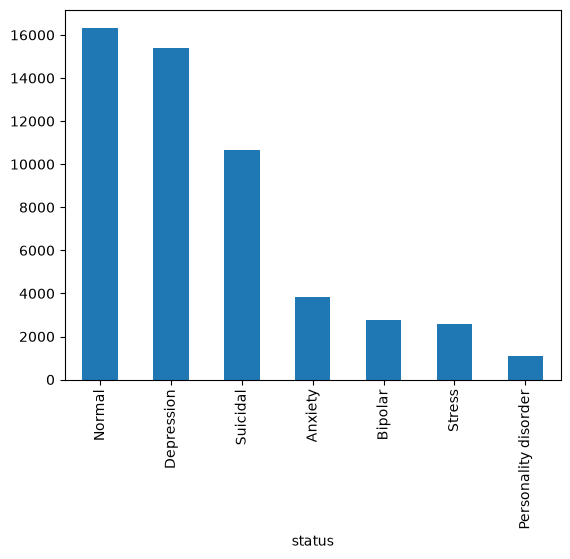

In [13]:
df['status'].value_counts().plot(kind='bar')

In [14]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["status"])

In [15]:
print(label_encoder.classes_)

['Anxiety' 'Bipolar' 'Depression' 'Normal' 'Personality disorder' 'Stress'
 'Suicidal']


In [16]:
print(df[["statement", "status", "label"]].head())

                                           statement   status  label
0                                         oh my gosh  Anxiety      0
1  trouble sleeping, confused mind, restless hear...  Anxiety      0
2  All wrong, back off dear, forward doubt. Stay ...  Anxiety      0
3  I've shifted my focus to something else but I'...  Anxiety      0
4  I'm restless and restless, it's been a month n...  Anxiety      0


In [19]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

In [20]:
train_small = train_df.sample(n=5000, random_state=42)
test_small = test_df.sample(n=1000, random_state=42)

print(train_small.shape)
print(test_small.shape)

(5000, 4)
(1000, 4)


In [21]:
print(train_small.columns)
print(test_small.columns)

Index(['Unnamed: 0', 'statement', 'status', 'label'], dtype='str')
Index(['Unnamed: 0', 'statement', 'status', 'label'], dtype='str')


In [ ]:
from transformers import AutoTokenizer

model_name = "distilbert/distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

In [ ]:
text = "I am feeling nervous"

tokens = tokenizer(text)

print(tokens)

In [ ]:
print(tokenizer.tokenize(text))